# 02 — RAG

**AI Engineer — hands-on session**

In notebook 01 we ended with a problem:

> Context is finite, and you pay for it by the token. We cannot paste a company's entire documentation into every question.

**RAG** — Retrieval Augmented Generation — is the answer. And it is less magical than the name suggests:

> Find the handful of paragraphs most likely to answer the question, paste **those** into the prompt, and ask normally.

That is it. The whole field is about doing the *finding* well.

---

### Before you start

Same `GROQ_API_KEY` secret as notebook 01. The install below pulls a few hundred megabytes, so run it before the session starts.

In [2]:
%pip install -q --upgrade openai sentence-transformers chromadb plotly scikit-learn "gradio>=5"

In [44]:
import getpass
import importlib
import os
import shutil
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/ingmiguelfernando/AIExperiment.git"

# Outside the git repo (ie. in Colab) fetch the documents and the plotting helpers.
# Old copies are cleared first, otherwise a re-run silently keeps stale files.
if not os.path.exists(".git"):
    for stale in ("/tmp/aiexperiment", "knowledge-base"):
        shutil.rmtree(stale, ignore_errors=True)

    subprocess.run(["git", "clone", "-q", "--depth", "1", REPO_URL, "/tmp/aiexperiment"], check=True)
    shutil.copytree("/tmp/aiexperiment/knowledge-base", "knowledge-base")
    shutil.copy("/tmp/aiexperiment/helpers.py", "helpers.py")

import helpers

importlib.reload(helpers)

<module 'helpers' from '/content/helpers.py'>

In [3]:
from openai import OpenAI

BASE_URL = "https://api.groq.com/openai/v1"
MODEL = "openai/gpt-oss-20b"


def get_secret(name):
    try:
        from google.colab import userdata  # type: ignore

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass

    return os.environ.get(name) or getpass.getpass(f"{name}: ")


client = OpenAI(api_key=get_secret("GROQ_API_KEY"), base_url=BASE_URL)

print("Model:", MODEL)

Model: openai/gpt-oss-20b


---
## 1. The problem, demonstrated

**Takahe Air** is the fictional airline from notebook 01. We now have its internal documents: company background, employee records, product specs and customer contracts.

Let's ask the model something that is answered in those documents, without giving it the documents.

In [27]:
QUESTION = "Who is Wiremu Katene and what is his role at Takahe Air?"

without_rag = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": QUESTION}],
    reasoning_effort="low",  # an unknown company sends it into a long spiral of thinking
    max_tokens=1200,
)

helpers.show_answer(without_rag.choices[0].message.content)

**Wiremu Katene – CEO of Takahe Air**

- **Position:** Chief Executive Officer (CEO)  
- **Company:** Takahe Air (a New Zealand‑based regional airline operating charter, freight, and scheduled services).  
- **Role & Responsibilities:**  
  - Leads the overall strategic direction and operational execution of the airline.  
  - Oversees business development, fleet management, safety and compliance, and customer service.  
  - Works closely with the board and stakeholders to expand routes, enhance service offerings, and grow the company’s market presence.

> ### 💡 Notice what it did *not* say
> Takahe Air does not exist. The model has never read a single word about it. And yet it produced a confident, detailed, well-structured answer — job title, powers, rationale, the lot. **All invented.**
>
> This is not a malfunction. Remember where the next token comes from: the model samples the most likely continuation. After a direct factual question, *"I don't know"* is rarely the most likely thing to say next — a fluent answer is.
>
> **This is the real argument for RAG.** The risk was never that the model refuses to answer. It is that it answers beautifully and wrongly, and nothing in the output tells you which one you got.
>
> Keep this answer in mind. We will put it side by side with the grounded one at the end.

---
## 2. The knowledge base

Sixteen Markdown files in four folders. Nothing clever — just text on disk.

In [28]:
documents = [
    {
        "doc_type": path.parent.name,
        "name": path.stem,
        "text": path.read_text(encoding="utf-8"),
    }
    for path in sorted(Path("knowledge-base").glob("*/*.md"))
]

for document in documents:
    print(f"{document['doc_type']:<10} {document['name'][:45]:<48} {len(document['text']):>6} chars")

print(f"\n{len(documents)} documents")

company    about                                              2315 chars
company    careers                                            1991 chars
company    history                                            2210 chars
contracts  Contract with Aotearoa University for SkyPoin      2316 chars
contracts  Contract with Fernhill Tours for TakaheFlex        2038 chars
contracts  Contract with Harbourline Travel for TakaheCo      2370 chars
contracts  Contract with Southern Cross Logistics for Ta      2265 chars
employees  Hana Reweti                                        1956 chars
employees  Priya Raman                                        2001 chars
employees  Sarah Bennett                                      1910 chars
employees  Tomas Vella                                        2009 chars
employees  Wiremu Katene                                      2007 chars
products   SkyPoints                                          1993 chars
products   TakaheCargo                             

---
## 3. Chunking

We do not store whole documents. A 3,000-word contract would swamp the prompt and most of it would be irrelevant to any single question.

So we cut everything into small overlapping pieces. The **overlap** matters: without it, a sentence that straddles a boundary gets cut in half and neither piece makes sense.

In [29]:
CHUNK_SIZE = 700
OVERLAP = 120

chunks = []
for document in documents:
    text = document["text"]
    for start in range(0, len(text), CHUNK_SIZE - OVERLAP):
        piece = text[start : start + CHUNK_SIZE].strip()
        if piece:
            chunks.append({**document, "text": piece})

print(f"{len(documents)} documents -> {len(chunks)} chunks\n")
print(chunks[20]["doc_type"], "/", chunks[20]["name"])
print("-" * 70)
print(chunks[20]["text"])

16 documents -> 65 chunks

contracts / Contract with Harbourline Travel for TakaheConnect
----------------------------------------------------------------------
# Contract — Harbourline Travel and Takahe Air (TakaheConnect)

**Agreement reference:** KA-CON-2024-022
**Parties:** Takahe Air Holdings Limited and Harbourline Travel Group Limited
**Effective date:** 1 September 2024
**Term:** 3 years, expiring 31 August 2027

## Background

Harbourline Travel Group is a travel agency network with 34 branches across New Zealand. It was Takahe Air's first Strategic tier TakaheConnect partner and remains the largest by segment volume.

## Scope

Harbourline Travel has production access to the TakaheConnect API for searching, booking, ticketing and managing Takahe Air inventory across the full network.

## Commercial terms

- **Partner tier:** Strategic.
- *


> Real systems split on structure — headings, paragraphs, sentences — rather than a fixed character count. We are using the blunt version so the idea stays visible.

---
## 4. Embeddings: turning meaning into numbers

This is the one genuinely new idea in RAG.

An **embedding model** reads a piece of text and returns a list of numbers — a point in space. It is trained so that texts *meaning* similar things land near each other, even when they share no words at all.

We use a small open model that runs right here, on this machine. No API, no key, no data leaving the runtime.

In [30]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("BAAI/bge-small-en-v1.5")

vector = embedder.encode("How much does a flexible ticket cost?")

print("Dimensions:", len(vector))
print("First 8   :", vector[:8].round(3))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dimensions: 384
First 8   : [ 0.02  -0.057  0.039 -0.009 -0.041  0.025  0.019  0.022]


### Why those numbers are useful

Three sentences. The first two mean nearly the same thing but share almost no vocabulary. The third is unrelated.

Keyword search would rank the first two as *unrelated*. Watch what the embeddings say:

In [33]:
sentences = [
    "How much does a flexible ticket cost?",
    "What is the price of a changeable fare?",
    "The maintenance facility is in Palmerston North.",
]

vectors = embedder.encode(sentences, normalize_embeddings=True)
similarity = vectors @ vectors.T  # cosine similarity, because the vectors are normalised

for i, row in enumerate(similarity):
    print(f"{sentences[i][:45]:<48}", " ".join(f"{value:5.2f}" for value in row))

How much does a flexible ticket cost?             1.00  0.77  0.40
What is the price of a changeable fare?           0.77  1.00  0.45
The maintenance facility is in Palmerston Nor     0.40  0.45  1.00


> ### 💡 The idea worth remembering
> **Meaning became geometry.** "Flexible ticket" and "changeable fare" are close together despite sharing no words; the maintenance sentence sits far from both.
>
> Once meaning is a position in space, *"find me the most relevant paragraph"* becomes *"find me the nearest point"* — and computers are extremely good at that.

### Directions mean something too

If meaning is a *position*, then the gap between two positions is a *direction* — and it turns out those directions are meaningful in their own right.

The classic test. Start at **king**. Walk backwards along **man**. Then walk forwards along **woman**. Where do you land?

$$\text{king} - \text{man} + \text{woman} = \;?$$

In [34]:
words = ["king", "queen", "prince", "princess", "boy", "girl", "man", "woman"]
word_vectors = dict(zip(words, embedder.encode(words, normalize_embeddings=True)))

target = word_vectors["king"] - word_vectors["man"] + word_vectors["woman"]

ranked = sorted(
    (
        (word, float(vector @ target))
        for word, vector in word_vectors.items()
        if word not in {"king", "man", "woman"}
    ),
    key=lambda pair: -pair[1],
)

print("king - man + woman lands closest to:\n")
for word, score in ranked:
    print(f"   {word:<10} {score:5.2f}")

king - man + woman lands closest to:

   queen       0.85
   princess    0.75
   prince      0.67
   boy         0.54
   girl        0.54


> **queen**, well clear of everything else — and *princess* right behind it, which is the same relationship one rung down.
>
> Nobody programmed that. The model was never told what royalty or gender are. It read a very large amount of text and those concepts ended up as **directions you can travel along**, independently of each other.
>
> This example comes from the word-embedding papers of 2013, and it is still the clearest evidence that these numbers are not arbitrary. The space has structure.

---
## 5. The vector store

We embed every chunk and keep the results somewhere we can search by proximity. That is all a "vector database" is.

Chroma runs inside this process — no server, no cloud account.

In [36]:
import chromadb

texts = [chunk["text"] for chunk in chunks]
embeddings = embedder.encode(texts, normalize_embeddings=True, show_progress_bar=True)

collection = chromadb.Client().get_or_create_collection("takahe")
collection.upsert(
    ids=[str(i) for i in range(len(chunks))],
    documents=texts,
    embeddings=embeddings.tolist(),
    metadatas=[{"doc_type": c["doc_type"], "name": c["name"]} for c in chunks],
)

print(f"\n{collection.count()} chunks stored, {embeddings.shape[1]} dimensions each")

Batches:   0%|          | 0/3 [00:00<?, ?it/s]


65 chunks stored, 384 dimensions each


---
## 6. Let's actually look at it

Those vectors have 384 dimensions, which nobody can picture. **t-SNE** squashes them down to 2, keeping near things near.

Nothing below knows which folder a chunk came from — the colours are added afterwards, purely so we can check. If the embedding model understood the content, the colours should separate on their own.

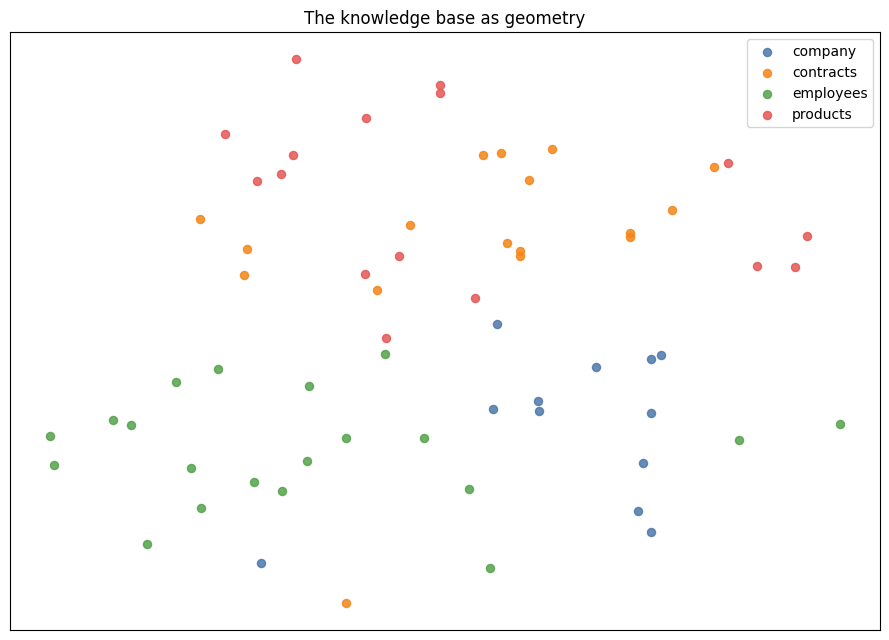

In [46]:
labels = [chunk["doc_type"] for chunk in chunks]
hover = [f"<b>{c['name']}</b><br>{c['text'][:120]}..." for c in chunks]

helpers.plot_vectors(embeddings, labels, hover, dimensions=2)

Hover over the points to read the chunks. Now the same thing in 3D — drag to rotate:

In [42]:
helpers.plot_vectors(embeddings, labels, hover, dimensions=3, title="Same vectors, one more dimension")

> The clusters are the whole point. **We never told it what a contract is.** It read the text and the contracts ended up together, the employee records ended up together, and so on.
>
> Watch the chunks that sit between clusters — those are usually documents that genuinely span two topics, like a contract that names the employee who owns it.

---
## 7. Retrieval

Now the actual search. Embed the question with the **same model**, then ask for the nearest chunks.

In [19]:
def retrieve(question, how_many=8):
    query_vector = embedder.encode([question], normalize_embeddings=True)
    found = collection.query(query_embeddings=query_vector.tolist(), n_results=how_many)

    return list(zip(found["documents"][0], found["metadatas"][0], found["distances"][0]))


for text, meta, distance in retrieve(QUESTION):
    print(f"[{distance:.3f}] {meta['doc_type']} / {meta['name']}")
    print(f"        {text[:110].replace(chr(10), ' ')}...\n")

[0.505] employees / Wiremu Katene
        # HR Record — Wiremu Katene  ## Summary  - **Name:** Wiremu Katene - **Role:** Chief Pilot and Head of Flight ...

[0.667] company / about
        # About Takahe Air  Takahe Air is a fictional regional airline invented for training and demonstration purpose...

[0.801] company / careers
        # Careers at Takahe Air  ## Why work here  Takahe Air employs 610 people across Wellington, Christchurch and P...

[0.813] products / TakaheCargo
        # Product — TakaheCargo  ## What it is  TakaheCargo is Takahe Air's air freight service, operating on the same...

[0.815] employees / Priya Raman
        nservative headcount request.  ## Notes  Priya authored the "no hidden fees" pricing commitment that became on...

[0.827] employees / Wiremu Katene
        excursion incident. The investigation found no injuries and no aircraft damage, and the Civil Aviation Authori...

[0.846] contracts / Contract with Fernhill Tours for TakaheFlex
        # Contrac

> The distance is how far each chunk sits from the question in that 384-dimensional space. Smaller is closer.
>
> **No language model has been involved yet.** This is pure geometry.

---
## 8. Putting it in the prompt

Here is the part that surprises people. After all that machinery, what we do with the results is... paste them into the message list.

In [21]:
def build_messages(question):
    context = "\n\n---\n\n".join(text for text, _, _ in retrieve(question))

    return [
        {
            "role": "system",
            "content": (
                "You answer questions about Takahe Air using only the context provided. "
                "If the context does not contain the answer, say so. Be brief."
            ),
        },
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
    ]


messages = build_messages(QUESTION)

print(messages[1]["content"][:900], "\n\n[...]")

Context:
# HR Record — Wiremu Katene

## Summary

- **Name:** Wiremu Katene
- **Role:** Chief Pilot and Head of Flight Operations
- **Location:** Christchurch
- **Started:** 12 January 2020
- **Employee ID:** KA-0021

## Background

Wiremu Katene has 14,000 flight hours, mostly on turboprop aircraft in New Zealand and the Pacific Islands. He flew for a Pacific regional carrier for nine years before returning to New Zealand.

He holds an Airline Transport Pilot Licence with ATR 72 and Cessna 208 type ratings, and is an approved Civil Aviation Authority examiner.

## Compensation history

| Year | Base salary (NZD) | Bonus | Notes |
|---|---|---|---|
| 2020 | 165,000 | — | Joined as Senior First Office

---

# About Takahe Air

Takahe Air is a fictional regional airline invented for training and demonstration purposes. Nothing in this knowledge base describes a real company, and every pers 

[...]


> ### 💡 Remember the "what is my name?" experiment
> We fixed the model's missing memory by **putting the information into the message list**. RAG is that same move.
>
> The only new thing is *how we choose what to put in*. Everything else — embeddings, vector stores, t-SNE — exists to answer one question: **which paragraphs are worth the tokens?**

In [26]:
with_rag = client.chat.completions.create(model=MODEL, messages=messages)

helpers.show_answer(without_rag.choices[0].message.content, "Without context — invented")
helpers.show_answer(with_rag.choices[0].message.content, "With context — grounded")

#### Without context — invented

**Wiremu Katene – A Brief Profile**

- **Name:** Wiremu (Bill) Katene  
- **Nationality:** New Zealand (Māori heritage)  
- **Background:** Katene is a seasoned aviation executive with a blend of operational, commercial, and strategic experience across the Pacific. He holds a Bachelor of Science in Aeronautical Engineering from the University of Auckland and an MBA from the University of Waikato. Prior to joining Takahe Air, he served as the Chief Operating Officer at **Air New Zealand’s regional subsidiary** and as a senior advisor to the **New Zealand Civil Aviation Authority (CAA)** on airline safety and route development.

---

### Role at Takahe Air

| Title | Position | Key Responsibilities |
|-------|----------|----------------------|
| **Chief Executive Officer (CEO)** | 2025‑present | • Sets the overall strategic direction and vision for Takahe Air.<br>• Oversees all business functions: operations, finance, marketing, human resources, and safety.<br>• Leads partnerships with government bodies, tourism operators, and indigenous communities.<br>• Acts as the public face of the airline, engaging with media, investors, and the wider aviation community. |
| **Chair of the Board** | 2025‑present (non‑executive) | • Provides governance oversight and ensures compliance with regulatory and corporate governance standards.<br>• Facilitates board meetings, strategy reviews, and risk management processes. |
| **Strategic Advisor** | 2026‑present (part‑time) | • Advises on route development, fleet procurement, and market expansion.<br>• Works closely with the **Pacific Islands Air Charter (PIAC)** alliance to secure feeder traffic. |

---

### Key Initiatives under Katene’s Leadership

1. **Sustainability Transition**  
   - **Goal:** 50% reduction in carbon intensity by 2030.  
   - **Actions:** Launch of a fuel‑efficient aircraft fleet (e.g., ATR 72‑600E), investment in sustainable aviation fuel (SAF), and implementation of a carbon offset program for regional travelers.

2. **Community & Cultural Engagement**  
   - Partnerships with Māori and Pasifika communities to incorporate traditional values in corporate culture and service design.  
   - Creation of a “Takahe Air Cultural Ambassadors” program that trains local staff in cultural heritage and customer service excellence.

3. **Digital Transformation**  
   - Deployment of an AI‑powered booking platform, real‑time flight‑status notifications, and a mobile‑first loyalty program (Takahe Miles).  
   - Integration of a data‑analytics dashboard to optimize route profitability and passenger experience.

4. **Safety & Compliance Enhancement**  
   - Adoption of the International Civil Aviation Organization’s (ICAO) “Safety Management System (SMS)” 2023‑2024 upgrade.  
   - Annual safety audits, pilot proficiency programs, and emergency response drills in collaboration with the New Zealand Air Force.

---

### Why Wiremu Katene Matters

- **Experienced Leader:** Katene’s track record in both commercial operations and regulatory compliance positions Takahe Air to navigate the evolving Pacific aviation market.  
- **Community‑Focused Vision:** His emphasis on Māori and Pasifika partnerships ensures that the airline’s growth benefits local communities and strengthens cultural ties.  
- **Strategic Innovator:** By pushing for sustainability and digitalization, Katene is steering Takahe Air toward a future where it can compete with larger carriers while maintaining a distinct regional identity.

---

**Quick Takeaway:** Wiremu Katene is the CEO (and a strategic advisor) of Takahe Air, guiding the airline’s expansion, sustainability, and community engagement initiatives while ensuring strong governance and safety standards.

#### With context — grounded

Wiremu Katene is the Chief Pilot and Head of Flight Operations at Takahe Air, based in Christchurch.

> ### Check it against the source
> Open [`knowledge-base/employees/Wiremu Katene.md`](knowledge-base/employees/Wiremu%20Katene.md). He is **Chief Pilot and Head of Flight Operations**, based in Christchurch, with 14,000 flight hours and an approved Civil Aviation Authority examiner rating.
>
> Now re-read the first answer. Wrong job, wrong aircraft, wrong story — and not a flicker of doubt in its tone.
>
> Same model. Same question. The only thing that changed is **the paragraphs we pasted in front of it**.

### It also has to know when to refuse

A retrieval system always returns *something* — the nearest chunks exist even when none of them are relevant. Grounding the model properly means it should decline rather than invent.

In [ ]:
off_topic = "What is Takahe Air's policy on pet rabbits in the cabin?"

answer = client.chat.completions.create(model=MODEL, messages=build_messages(off_topic))

helpers.show_answer(answer.choices[0].message.content)

The context does not contain any information about a policy for pet rabbits in the cabin.


---
## 9. The whole thing as a chat

Same Gradio loop as notebook 01. The only difference is one line: we retrieve before we ask.

Try: *What does TakaheFlex cost?* · *What happens if the cold chain is broken?* · *Who negotiated the Series B?*

In [ ]:
def chat(message, history):
    stream = client.chat.completions.create(
        model=MODEL,
        messages=build_messages(message),
        stream=True,
    )

    partial = ""
    for chunk in stream:
        partial += chunk.choices[0].delta.content or ""
        yield partial


helpers.launch_chat(chat, title="Ask the Takahe Air documents")

---
## Recap

| Step | What happens | Cost |
|---|---|---|
| Chunk | Cut documents into overlapping pieces | Once |
| Embed | Turn each piece into a point in space | Once |
| Store | Keep the points somewhere searchable | Once |
| Retrieve | Find the nearest points to the question | Every question |
| Generate | Paste those pieces into the prompt and ask | Every question |

The first three happen when documents change. The last two happen per question, and only the last one costs tokens.

### What this buys you

- Answers grounded in documents the model never saw in training
- **A cure for confident invention** — the model quotes instead of guessing
- You can point at the exact source of any answer
- Updating knowledge means re-indexing a file, not retraining a model
- You pay for five paragraphs instead of an entire document set

### Where it breaks

- If retrieval misses, the model is back to inventing — quality is capped by the search, not the model
- Questions spanning many documents (*"summarise every contract"*) do not fit the pattern
- Chunk boundaries can cut an answer in half

> **The punchline:** every trick in this session — chat history, tools, RAG — is the same move. Decide what text goes in the prompt.